# 2D Grey–Scott Reaction–Diffusion Equation

The Grey–Scott system models two interacting chemical species $u$ and $v$:

$$u_t = \varepsilon_1\,\Delta u + b_1(1 - u) - c_1\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$
$$v_t = \varepsilon_2\,\Delta v - b_2\,v + c_2\,u\,v^2, \quad (x,y) \in (-1,1)^2,\;t \in (0,2)$$

**Periodic boundary conditions** on both $x$ and $y$.

**Initial conditions:**
$$u_0(x,y) = 1 - e^{-10\left((x+0.05)^2+(y+0.02)^2\right)}$$
$$v_0(x,y) = e^{-10\left((x-0.05)^2+(y-0.02)^2\right)}$$

**Parameters:** $\varepsilon_1=0.2$, $\varepsilon_2=0.1$, $b_1=40$, $b_2=100$, $c_1=c_2=1000$.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp

## Domain

$(x,y) \in [-1,1]^2$, $t \in [0,2]$. Periodic BCs on both spatial axes.


In [2]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],  # (x_min, x_max), (y_min, y_max)
    time =np.linspace(0.0, 2.0, 11),   # 10 time partitions: [0, 0.2, 0.4, …, 2.0]
)

## PDE Residuals

Two coupled residuals, one per species. The network outputs $[u, v]$.

$$\mathcal{R}_u = u_t - \varepsilon_1(u_{xx} + u_{yy}) - b_1(1-u) + c_1 u v^2 = 0$$
$$\mathcal{R}_v = v_t - \varepsilon_2(v_{xx} + v_{yy}) + b_2 v - c_2 u v^2 = 0$$


In [3]:
import jax

problem = pinns.ProblemStrong(domain=domain, output_names=["u", "v"])

def grey_scott_residual(X, U, params, derivative=None):
    # X columns: 0=x, 1=y, 2=t
    p = params
    eps1 = p['eps1'];  eps2 = p['eps2']
    b1   = p['b1'];    b2   = p['b2']
    c1   = p['c1'];    c2   = p['c2']

    u = U[:, 0:1]
    v = U[:, 1:2]

    dt_all   = derivative.all(X, (2,))       # (N, 2): [u_t,  v_t ]
    dxx_all  = derivative.all(X, (0, 0))     # (N, 2): [u_xx, v_xx]
    dyy_all  = derivative.all(X, (1, 1))     # (N, 2): [u_yy, v_yy]

    u_t  = dt_all[:,  0:1];  v_t  = dt_all[:,  1:2]
    u_xx = dxx_all[:, 0:1];  v_xx = dxx_all[:, 1:2]
    u_yy = dyy_all[:, 0:1];  v_yy = dyy_all[:, 1:2]

    uv2 = u * v**2

    res_u = u_t - eps1 * (u_xx + u_yy) - b1 * (1.0 - u) + c1 * uv2
    res_v = v_t - eps2 * (v_xx + v_yy) + b2 * v          - c2 * uv2

    return jnp.concatenate([res_u, res_v], axis=1)   # (N, 2)

problem.add_inner(grey_scott_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    y = X[:, 1:2]
    u0 = 1.0 - jnp.exp(-10.0 * ((x + 0.05)**2 + (y + 0.02)**2))
    v0 =       jnp.exp(-10.0 * ((x - 0.05)**2 + (y - 0.02)**2))   
    return jnp.concatenate([u0, v0], axis=1)   # (N, 2)

problem.add_initial(u_initial, name="initial", outputs=["u", "v"])

problem.add_parameter("eps1", 0.2)

problem.add_parameter("eps2", 0.1)

problem.add_parameter("b1",   40.0)
problem.add_parameter("b2",   100.0)
problem.add_parameter("c1",   1000.0)
problem.add_parameter("c2",   1000.0)


ProblemStrong(domain=DomainCubic, n_dims=3, n_outputs=2, inner=1, boundary=0, initial=2, params=['eps1', 'eps2', 'b1', 'b2', 'c1', 'c2'], trainable=[])

### Reference Solution (pseudo-spectral ETD2RK)

Both species are evolved spectrally on a 2-D periodic grid using `ModelSolver` +
`IntegratorETD2RK` (Cox–Matthews exponential time differencing).  In Fourier space:

$$\partial_t \hat{u}_\mathbf{k} = \underbrace{-\varepsilon_1 |\mathbf{k}|^2 \hat{u}_\mathbf{k}}_{\text{linear (exact)}} + \underbrace{\widehat{b_1(1-u) - c_1 u v^2}}_{\text{nonlinear}}$$

`IntegratorETD2RK` treats the stiff diffusion exactly via matrix exponentials
(pointwise in Fourier space), avoiding the small-step restriction of explicit methods.


U_ref shape: (201, 128, 128)  range [0.0003, 1.0000]
V_ref shape: (201, 128, 128)  range [-0.0015, 0.9997]


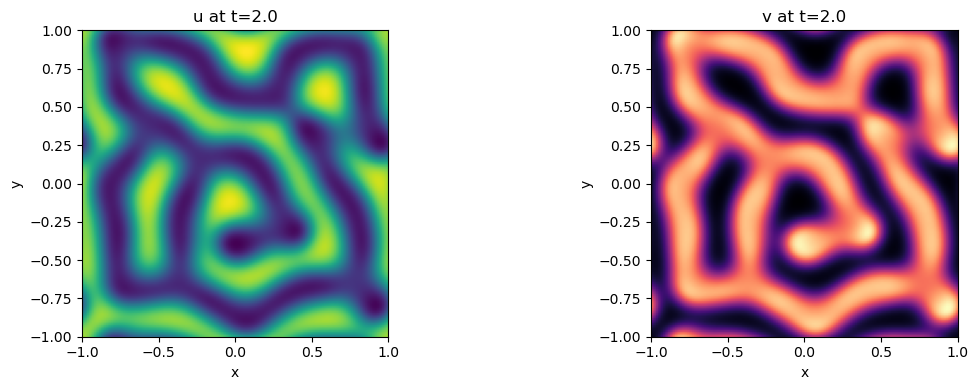

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# ── Parameters ────────────────────────────────────────────────────────────────
eps1_val = 0.2;    eps2_val = 0.1
b1_val   = 40.0;   b2_val   = 100.0
c1_val   = 1000.0; c2_val   = 1000.0

Nx = Ny = 128
Nt = 201        # saved snapshots (includes t=0)
T  = 2.0

t_ref = np.linspace(0.0, T, Nt)

# ── DomainGrid (2D periodic Fourier basis) ─────────────────────────────────
domain_grid = pinns.DomainGrid(
    space=[(-1.0, 1.0), (-1.0, 1.0)],
    shape=(Nx, Ny),
    bc="periodic",
    time=(0.0, T),
)
x_ref = np.array(domain_grid._grids[0])   # (Nx,)
y_ref = np.array(domain_grid._grids[1])   # (Ny,)

# ── ModelSolver ───────────────────────────────────────────────────────────────
#   Linear part:  L_u = -eps1*K², L_v = -eps2*K²  (exact in Fourier space)
#   Nonlinear:    N_u = b1*(1-u) - c1*u*v²,  N_v = -b2*v + c2*u*v²

integrator_gs = pinns.IntegratorETD2RK(dt=1e-4, checkpoint=False)

model_gs = pinns.ModelSolver(domain_grid, ["u", "v"], integrator_gs)

model_gs.set_linear_op(
    lambda K2, p: {
        "u": -p["eps1"] * K2,
        "v": -p["eps2"] * K2,
    }
)

def gs_nonlinear(state_hat, p):
    u   = domain_grid.inverse(state_hat["u"])
    v   = domain_grid.inverse(state_hat["v"])
    uv2 = u * v**2
    Nu  = p["b1"] * (1.0 - u) - p["c1"] * uv2
    Nv  = -p["b2"] * v        + p["c2"] * uv2
    return {
        "u": domain_grid.forward(Nu),
        "v": domain_grid.forward(Nv),
    }

model_gs.set_nonlinear_op(gs_nonlinear)
model_gs.add_parameter("eps1", eps1_val)
model_gs.add_parameter("eps2", eps2_val)
model_gs.add_parameter("b1",   b1_val)
model_gs.add_parameter("b2",   b2_val)
model_gs.add_parameter("c1",   c1_val)
model_gs.add_parameter("c2",   c2_val)

# ── Initial conditions ────────────────────────────────────────────────────────
XX, YY = np.meshgrid(x_ref, y_ref, indexing='ij')
u0 = jnp.array(1.0 - np.exp(-10.0 * ((XX + 0.05)**2 + (YY + 0.02)**2)))
v0 = jnp.array(      np.exp(-10.0 * ((XX - 0.05)**2 + (YY - 0.02)**2)))

model_gs.add_initial({"u": u0, "v": v0})

# ── Forward solve ─────────────────────────────────────────────────────────────
sol = model_gs.solve(t_obs=t_ref)
U_ref = np.array(sol["u"])   # (Nt, Nx, Ny)
V_ref = np.array(sol["v"])   # (Nt, Nx, Ny)

print(f"U_ref shape: {U_ref.shape}  range [{U_ref.min():.4f}, {U_ref.max():.4f}]")
print(f"V_ref shape: {V_ref.shape}  range [{V_ref.min():.4f}, {V_ref.max():.4f}]")

# ── Interpolants: X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2) ──────────────────────
_interp_u = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    U_ref.transpose(1, 2, 0),   # (Nx, Ny, Nt)
    method='linear', bounds_error=False, fill_value=None,
)
_interp_v = RegularGridInterpolator(
    (x_ref, y_ref, t_ref),
    V_ref.transpose(1, 2, 0),
    method='linear', bounds_error=False, fill_value=None,
)

def uv_reference(X):
    """X[:,0]=x, X[:,1]=y, X[:,2]=t → (N,2)"""
    pts = np.asarray(X)[:, :3]
    return np.concatenate([
        _interp_u(pts)[:, None],
        _interp_v(pts)[:, None],
    ], axis=1)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(U_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='viridis')
axes[0].set_title(f"u at t={T}"); axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[1].imshow(V_ref[-1], extent=(-1,1,-1,1), origin='lower', cmap='magma')
axes[1].set_title(f"v at t={T}"); axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.tight_layout()

## Network Architecture

Input is 3D $(x, y, t)$, output is 2D $(u, v)$.
`tanh` output activation keeps both concentrations in $[0, 1]$,
consistent with the physical range of the Grey–Scott system.


In [5]:
domain.set_partition(
    time=10,
    # space=[3,3]                                                      
)

template = pinns.ModelBase(domain, 2)

template.add(pinns.Normalize())
template.add(pinns.PeriodicEmbedding(["x", "y"]))
template.add(pinns.FourierFeatures(256, sigma=1.0))
template.add(pinns.PirateNet(256, 3, rwf_mu=0.5, rwf_sigma=0.1, output_activation="sigmoid"))

# 10 time-partition sub-nets, assembled via overlapping window functions (FB-PINN)
network = pinns.ModelPartitioned(template, pinns.PartitionFB(), partition_time=True)

## Training

The model uses **temporal curriculum via `SchedulerPartition`**: at each stage a sliding
window of 2 consecutive time-partition sub-nets is active.  Every 50 000 epochs the window
advances by one slot, progressively covering $t \in [0, 2]$ across 10 partitions.

`SchedulerCausal` enforces within-window causal ordering (earlier time gets larger weight),
while `SchedulerResample` refreshes collocation points each epoch.

Starting training for 500000 epochs (JIT-compiled)...


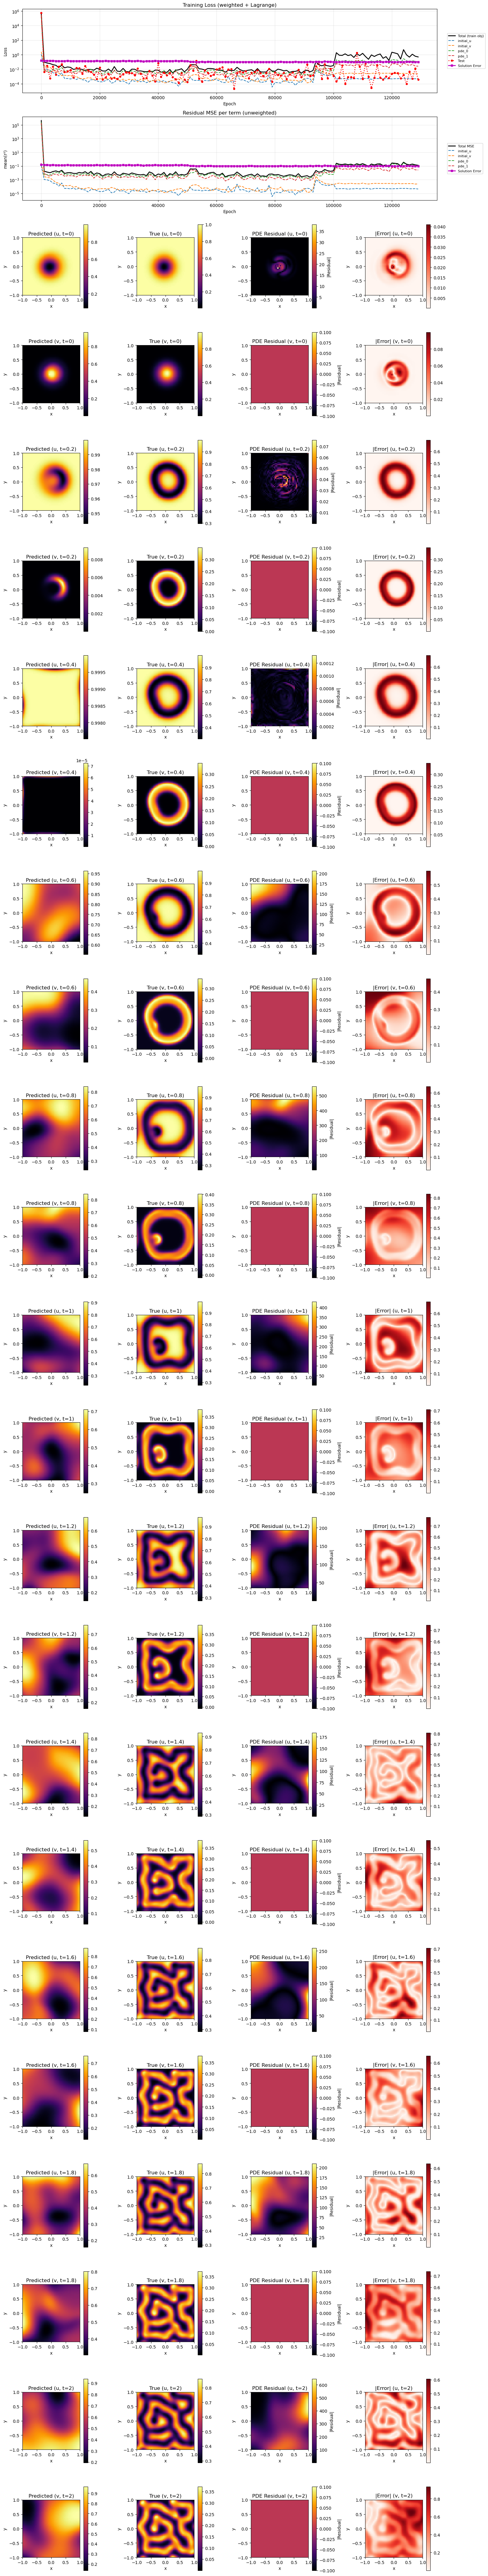

Epoch 0/500000 | Loss: 4.39e+05 | MSE: 4.39e+05 | Terms: [initial_u: 1.16e-01, initial_v: 2.47e-01, pde_0: 2.51e+05, pde_1: 1.89e+05] | Test Loss: 5.67e+05 | Error: 1.63e-01 | Time: 0.0s
Epoch 1000/500000 | Loss: 9.47e-02 | MSE: 1.76e-02 | Terms: [initial_u: 1.05e-03, initial_v: 2.93e-03, pde_0: 5.10e-03, pde_1: 8.52e-03] | Test Loss: 4.25e-03 | Error: 1.43e-01 | Time: 284.4s
Epoch 2000/500000 | Loss: 7.13e-02 | MSE: 1.31e-02 | Terms: [initial_u: 9.51e-04, initial_v: 2.11e-03, pde_0: 5.67e-03, pde_1: 4.35e-03] | Test Loss: 3.05e-02 | Error: 1.42e-01 | Time: 484.4s
Epoch 3000/500000 | Loss: 5.96e-02 | MSE: 1.05e-02 | Terms: [initial_u: 7.12e-04, initial_v: 1.85e-03, pde_0: 4.80e-03, pde_1: 3.11e-03] | Test Loss: 5.45e-04 | Error: 1.38e-01 | Time: 684.2s
Epoch 4000/500000 | Loss: 4.25e-02 | MSE: 1.56e-02 | Terms: [initial_u: 3.26e-04, initial_v: 8.69e-04, pde_0: 8.41e-03, pde_1: 5.98e-03] | Test Loss: 2.22e-02 | Error: 1.43e-01 | Time: 884.1s
Epoch 5000/500000 | Loss: 3.48e-02 | MSE: 1.9

KeyboardInterrupt: 

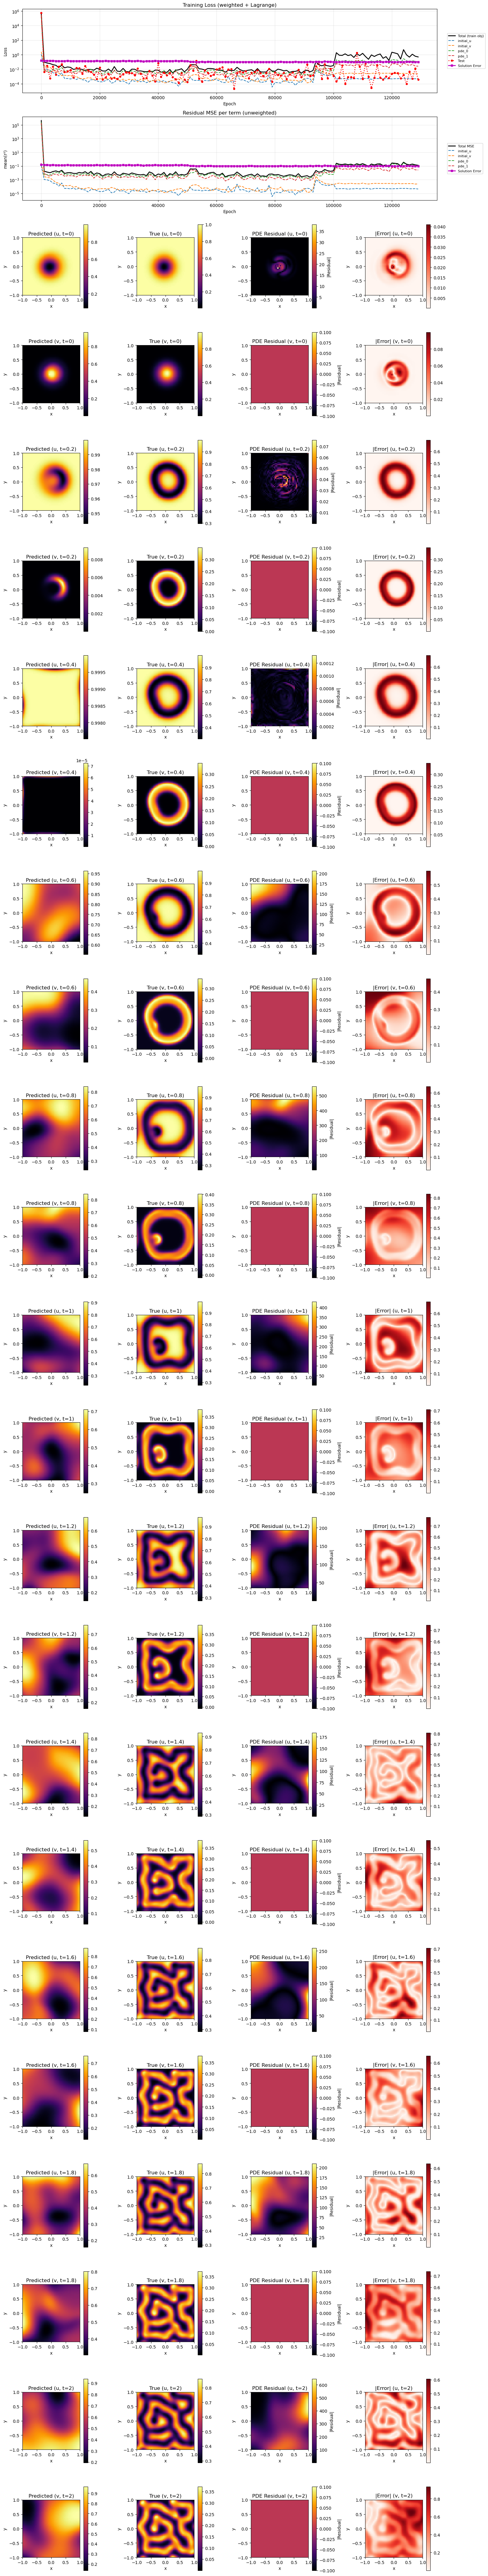

: 

In [ ]:
trainer = pinns.Trainer(network, problem=problem)

trainer.add_solution(uv_reference)

trainer.compile(
    problem = {
        "pde":      {"train": 2000, "test": 10, "weight": 1.0},
        "initial":  {"train": 1000, "test": 10, "weight": 10.0},
    },
    optimizer=pinns.SOAPOptimizer(),
    schedulers=[
        pinns.SchedulerResample(1),
        pinns.SchedulerCausal(term="pde", tol=1.0, n_chunks=16, t_col=2),
        pinns.SchedulerPartition(
            epochs_per_partition=50_000,  # advance window every 50k epochs
            t_col=2,                      # time is the 3rd input column (x, y, t) 
            window=2,                     # 2-subnet sliding window
            reset_optimizer=True,         # zero moments when a new subnet activates
        ),
    ],
    epochs=500_000,
    print_each=1000,
    show=pinns.TrainPlotter(
        time_points=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0],
    )
)

trainer.train()
